In [1]:
import sys
sys.path.append('../..')
sys.path.append('.')
sys.path.append('..')

In [107]:
from functools import partial

import numpy as np

import torch
from torch import nn

from matplotlib import pyplot as plt
from matplotlib import colors, cm



from ansatz_utils.neural_networks import MLP
from ansatz_utils.permutation_actions import all_transpositions
from ansatz_utils.projective_layers import AnInvariantEmbedding


%matplotlib inline

In [3]:
def make_transpositions(_x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    *size, d, n = _x.shape
    at = all_transpositions(_x.shape[-2], _x.device).unsqueeze(0).unsqueeze(-1)
    for i in range(len(size)-1):
        at = at.unsqueeze(2)
    
    shaped_input = _x.clone().unsqueeze(1)
    trans_input = torch.take_along_dim(shaped_input, at, -2)
    # print(shaped_input.shape, trans_input.shape, _x.shape)
    return shaped_input, trans_input
    

def nl_wso(function: nn.Module, _input: torch.Tensor) -> torch.Tensor:    
    si, ti = make_transpositions(_input)

    f1 = function(si)
    f2 = function(ti)

    f_out = (f1.sign() * torch.sqrt(0.5 * f1.abs() * (f1 - f2).abs().min(dim=1, keepdims=True)[0])).mean(dim=1)
    
    return f_out


def l_wso(function: nn.Module, _input: torch.Tensor) -> torch.Tensor:    
    si, ti = make_transpositions(_input)


    w = (si - ti).norm(dim=(-2, -1))
    ws = w.sum(dim=1, keepdims=True)    
    

    f1 = function(si)
    f2 = function(ti)

    f_out = (f1.sign() * torch.sqrt(0.5 * f1.abs() * (f1 - f2).abs().min(dim=1, keepdims=True)[0])).mean(dim=1)
    
    return f_out

In [4]:
def prod_all_but_one(X: torch.Tensor) -> torch.Tensor:
    size = X.size(-1)
    if size == 1:
        return torch.ones_like(X)
    return torch.cat([X[..., :i].prod(-1, True) * X[..., i+1:].prod(-1, True) for i in range(size)], dim=-1)

In [5]:
#xx = (xs - xt).norm(dim=(-2, -1))

# prod_all_but_one(xx) / (prod_all_but_one(xx).sum() + xx.prod())

In [189]:
N = 100
u, l = 2, -2
X = np.linspace(l, u, N)
X, Y = np.meshgrid(X, X)
x = np.vstack(list(map(np.ravel, [X, Y]))).T[..., None]

x = np.stack([x, x[:, ::-1]], axis=-2)[..., 0]
x = torch.tensor(x, dtype=torch.float64)#.T.reshape(-1, 2, 2))
print(torch.prod(x))

# det = torch.det(Q).unsqueeze(1)
# Q[:, 0] = torch.where(det < 0, -Q[:, 0], Q[:, 0] )
#x = torch.matmul(x, Q)
#x = torch.matmul(Q.transpose(2, 1), x)

xs, xt = make_transpositions(x)
xx = (xs - xt).norm(dim=(-2, -1)).min(dim=1)[0].detach().numpy() / N

tensor(0., dtype=torch.float64)


In [174]:
#mlp_in = nn.Sequential(nn.Flatten(-2, -1), MLP(4, 8, device=x.device, activation='tanh', dtype=x.dtype))
#embedd = AnInvariantEmbedding(2, 2, 8).to(device=x.device, dtype=x.dtype)
#mlp_out = MLP(8, 1, [16, 4, 2], device=x.device, activation='tanh', dtype=x.dtype)

f1 = nn.Sequential(mlp_in, nn.Tanh(), mlp_out)
f2 = nn.Sequential(embedd, nn.Tanh(), mlp_out)

nlws_f1 = partial(nl_wso, f1)
nlws_f2 = partial(nl_wso, f2)

In [190]:
p1 = f1(x).abs().detach().numpy().reshape(X.shape).T
p2 = nlws_f1(x).abs().detach().numpy().reshape(X.shape).T
# p3 = f2(x).abs().detach().numpy().reshape(X.shape).T
p4 = nlws_f2(x).abs().detach().numpy().reshape(X.shape).T

In [191]:
# vmin1 = min(p1.min(), p2.min())
# vmin2 = min( p3.min(), p4.min())
# vmax1 = max(p1.max(), p2.max())
# vmax2 = max(p3.max(), p4.max())

vmx = max(xx.max(), p2.max(), p4.max(), p1.max())

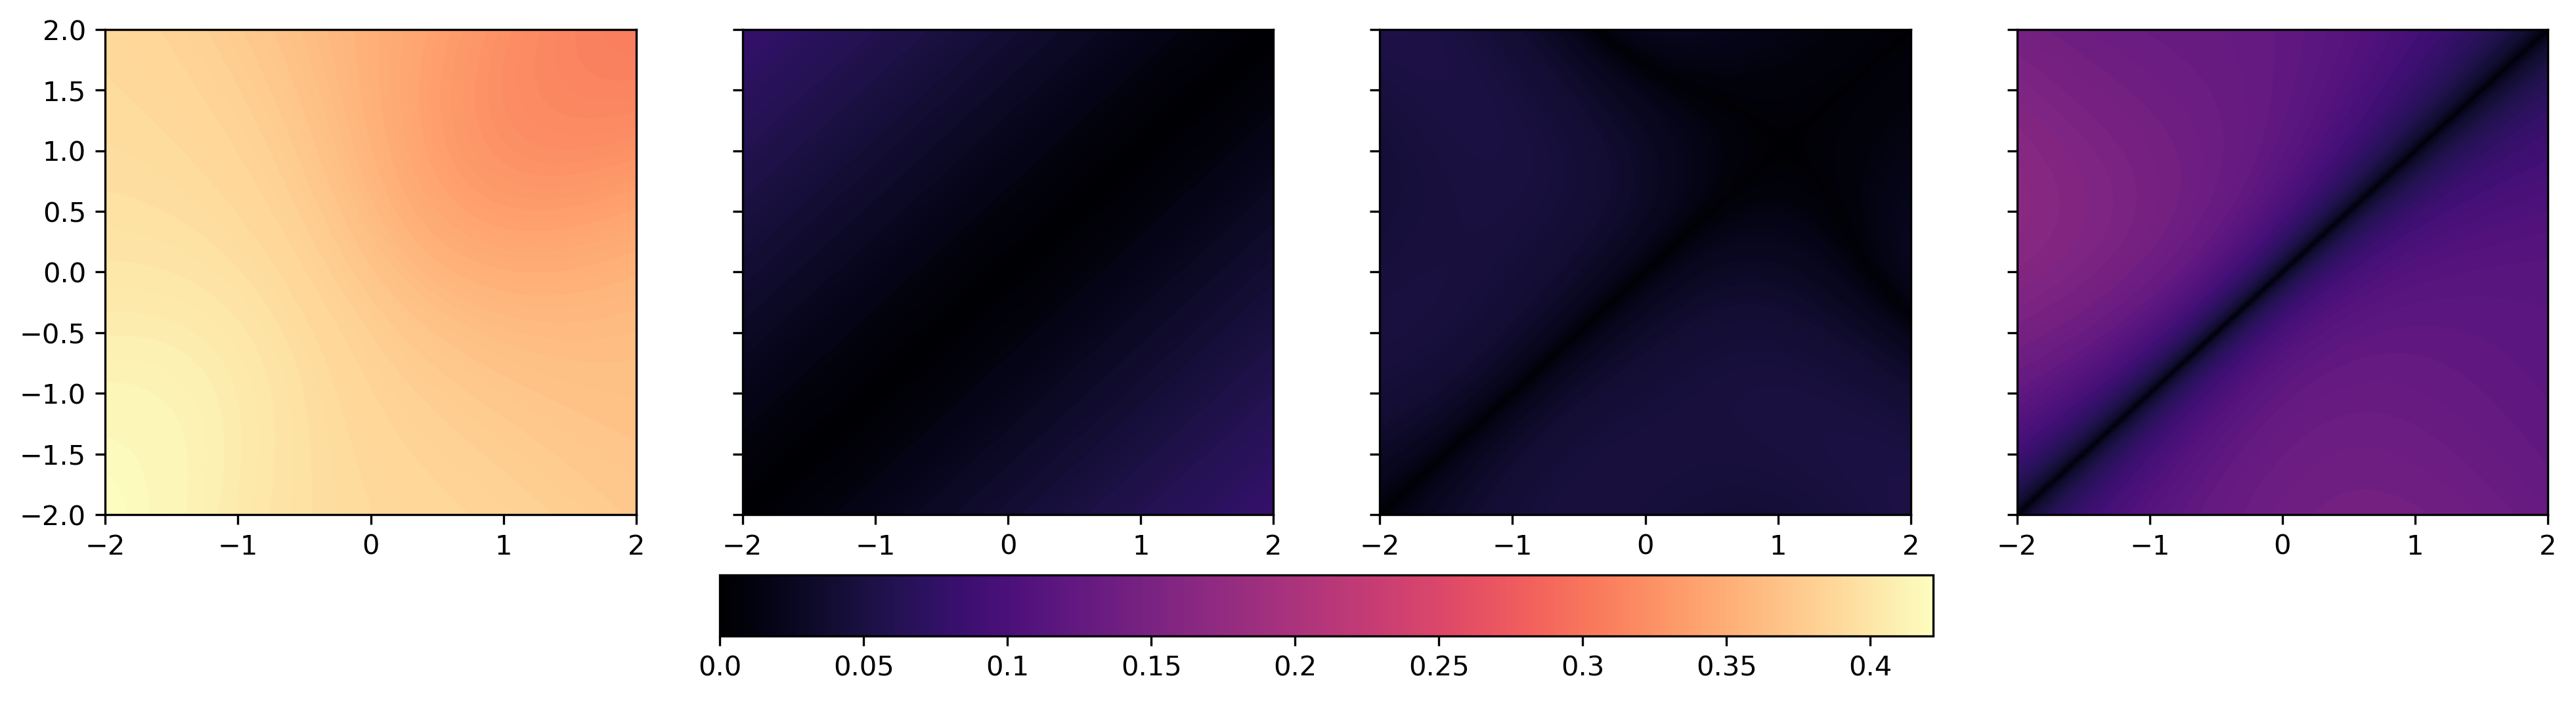

In [193]:
# plt.figure(figsize=(16, 8), dpi=130)
fig, ax = plt.subplots(1, 4, sharey=True, figsize=(16, 4), dpi=300)
LEVELS = 50

norm = colors.Normalize(0, vmx)
# out = [[p1, xx.reshape(X.shape).T], [p2, p4]]
out = [p1, xx.reshape(X.shape).T, p2, p4]
plots=[]
for i in range(len(out)):
    plots.append(ax[i].contourf(X, Y, out[i], levels=LEVELS, norm=norm, cmap='magma'))

#for i in range(2):
#    for j in range(2):
#        plots.append(ax[i, j].contourf(X, Y, out[i][j], levels=LEVELS, norm=norm, cmap='twilight'))


#ax[1, 0].set_xlabel(r"$x_1$")
#ax[1, 0].set_ylabel(r"$x_2$")
#ax[1, 1].set_xlabel(r"$x_1$")
#ax[0, 0].set_ylabel(r"$x_2$")
fig.colorbar(cm.ScalarMappable(norm, cmap='magma'), ax=ax, pad=0.1, format="{x:.2}", orientation='horizontal', fraction=.1)
# plt.tight_layout()
plt.savefig("wsop_gen.pdf", format='pdf')
plt.show()

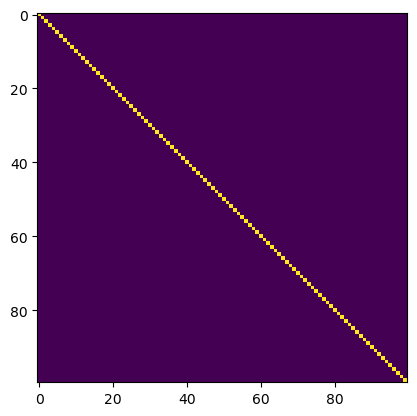

In [178]:
plt.imshow(np.isclose(p4, 0, atol=1e-4))

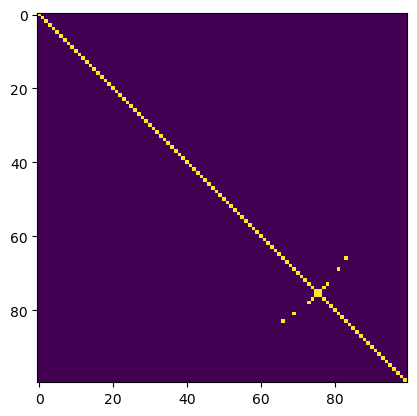

In [180]:
plt.imshow(np.isclose(p2, 0, atol=1e-3))